# Zero-Order-Hold Multiple Shooting leg

The Zero-Order-Hold Multiple Shooting (ZOH-MS) trajectory leg is available as {class}`pykep.leg.zoh_ms`, implemented in C++. The pure-Python version, {class}`pykep.leg.zoh_ms_py`, has the same public interface and is intended to be a reference implementation.

In 'pykep' version of the multiple shooting technique, we divide the trajectory into short segments and store a state at every mesh node. We propagate each segment and compare the result with the state stored at the other end. This difference is called a **continuity defect** or simply **defect**. If every defect is zero, the segments join into one continuous trajectory. Segments are propagated forward or backward depending on the `cut` parameter, making the multiple shooting leg directly comparable to the {class}`pykep.leg.zoh` leg based on single fwd-bck shooting.

In the Keplerian example, each node stores the seven-component state $\mathbf{x}_k=[x_k,y_k,z_k,v_{x,k},v_{y,k},v_{z,k},m_k]$: position, velocity and mass. A mesh with $n$ segments therefore has $n+1$ nodes and $7n$ scalar continuity constraints.

The control is held constant within each segment, which is the meaning of *zero-order hold*. For the Keplerian example, the four control components are

$$
\mathbf{u}_k = [T_k,\ i_{x,k},\ i_{y,k},\ i_{z,k}],
$$

where $T_k$ is the thrust magnitude and $(i_{x,k},i_{y,k},i_{z,k})$ is its direction in the inertial frame. A physical thrust direction has unit length. The generic leg does not enforce physical bounds or normalize the direction; these choices belong to the supplied dynamics and the optimization problem.

Let $\Phi_k(\mathbf{x}_k;\mathbf{u}_k)$ denote propagation from $t_k$ to $t_{k+1}$. The parameter `cut`, between 0 and 1, sets the number of forward-propagated segments: $n_{\mathrm{fwd}}=\lfloor n\,\mathrm{cut}\rfloor$. Each forward segment starts at its own left-hand mesh node; each backward segment starts at its own right-hand mesh node. The defect is

$$
\mathbf{d}_k =
\begin{cases}
\Phi_k(\mathbf{x}_k;\mathbf{u}_k)-\mathbf{x}_{k+1}, & 0 \le k < n_{\mathrm{fwd}}, \\
\mathbf{x}_k-\Phi_k^{-1}(\mathbf{x}_{k+1};\mathbf{u}_k), & n_{\mathrm{fwd}} \le k < n.
\end{cases}
$$

Here $\Phi_k^{-1}$ means integrating the same dynamics backward from $t_{k+1}$ to $t_k$. Both directions describe the same continuous trajectory when the defects are zero, although their nonzero defect values can differ.

`compute_defects()` returns the defect components flattened in segment order. The leg also provides their analytical derivatives with respect to the node states, controls and time grid. Together, these derivatives form the **Jacobian matrix**.

We start with the required imports:

In [1]:
import pykep as pk
import numpy as np
import pygmo as pg
from copy import deepcopy

%matplotlib inline

In [2]:
# Smaller integrator tolerances request greater accuracy and usually take more computation.
tol = 1e-10
tol_var = 1e-6

# The nominal integrator propagates the seven state components.
# The variational integrator also propagates their sensitivities to states and controls.
# We use a looser tolerance for sensitivities; tighten it if more accurate derivatives are needed.
ta_global = pk.ta.get_zoh_kep(tol)
ta_var_global = pk.ta.get_zoh_kep_var(tol_var)

# Parameter 4 is 1/veff. Choose dimensionless veff = 1 so thrust consumes mass.
# Mass changes then contribute to the defects and their derivatives.
ta_global.pars[4] = ta_var_global.pars[4] = 1.0

# Divide SI positions, times, velocities and masses by these scales.
# With this choice of time scale, the dimensionless gravitational parameter is 1.
L = pk.AU
MU = pk.MU_SUN
TIME = np.sqrt(L**3 / MU)
V = L / TIME
MASS = 1000.0

# 1 - Validate the Zero-Order-Hold multiple-shooting leg

We check the analytical Jacobian against finite-difference estimates. Finite differences approximate a derivative by changing an input slightly and observing the change in the defects.

The Jacobian is **sparse**: a segment depends only on its nearby nodes, its own controls and its two endpoint times. Most matrix entries are therefore zero. The *sparsity pattern* lists the matrix positions where derivatives can be nonzero, so we do not need to store a full matrix of mostly zeros.

We first construct the mesh states, controls and time grid, then evaluate the defects and gradients. The following helper changes one input on a copy of the leg, leaving the original leg unchanged:

In [3]:
def compute_defects_n(leg_mod, name, values):
    """Evaluate the defects after changing one input on a copy of the leg."""
    setattr(leg_mod, name, values)
    return leg_mod.compute_defects()

We create a reference mesh from a Lambert transfer between Earth and Mars. A Lambert solution is a two-body, zero-thrust trajectory connecting two positions in a specified flight time.

We then apply nonzero thrust to those reference nodes. The resulting leg is deliberately infeasible: the stored nodes generally do not match propagation with the selected controls. This gives us nonzero defects to use in the derivative check.

The dimensional positions and velocities are converted to the units defined above. 

In [4]:
# Get Earth's position at departure and Mars's position at arrival.
pl0 = pk.planet(pk.udpla.jpl_lp("earth"))
epoch0 = pk.epoch(1345.0, pk.epoch.julian_type.MJD2000)
posvel0 = pl0.eph(epoch0)
pl1 = pk.planet(pk.udpla.jpl_lp("mars"))
epoch1 = pk.epoch(1745.0, pk.epoch.julian_type.MJD2000)
posvel1 = pl1.eph(epoch1)

# Solve for a zero-thrust transfer with this flight time, expressed in seconds.
tof = (epoch1.mjd2000 - epoch0.mjd2000) * pk.DAY2SEC
lambert = pk.lambert_problem(r0=posvel0[0], r1=posvel1[0], tof=tof, mu=pl0.mu_central_body)

# Sample ten nodes on the reference transfer: ten nodes give nine segments.
N = 10
r0, v0 = posvel0[0], lambert.v0[0]
tgrid = np.linspace(0, tof, N)
states = pk.propagate_lagrangian_grid([r0, v0], tgrid, pl0.mu_central_body)

# Store each node as dimensionless position, velocity and mass, in that order.
states_flattened_nd = []
for state in states:
    states_flattened_nd.extend([position / L for position in state[0]])
    states_flattened_nd.extend([velocity / V for velocity in state[1]])
    states_flattened_nd.append(1.0)
tgrid_nd = tgrid / TIME

# Apply nonzero thrust in the positive inertial y direction to the ballistic nodes.
controls_nd = [0.2, 0.0, 1.0, 0.0] * (N - 1)
leg = pk.leg.zoh_ms(
    states_flattened_nd, controls_nd, tgrid_nd, cut=0.5, tas=[ta_global, ta_var_global]
)

We now compute the defects and their analytical sparse Jacobian. Stack the node states, controls, times and defects as

$$
\mathbf{X}=\begin{bmatrix}\mathbf{x}_0\\ \vdots\\ \mathbf{x}_n\end{bmatrix},
\qquad
\mathbf{U}=\begin{bmatrix}\mathbf{u}_0\\ \vdots\\ \mathbf{u}_{n-1}\end{bmatrix},
\qquad
\mathbf{T}=\begin{bmatrix}t_0\\ \vdots\\ t_n\end{bmatrix},
\qquad
\mathbf{D}=\begin{bmatrix}\mathbf{d}_0\\ \vdots\\ \mathbf{d}_{n-1}\end{bmatrix}.
$$

With `cut` held fixed, the defect Jacobian is

$$
J=\frac{\partial\mathbf{D}}{\partial(\mathbf{X},\mathbf{U},\mathbf{T})}
=\begin{bmatrix}J_X & J_U & J_T\end{bmatrix},
$$

where each row corresponds to a defect component and each column to an input component:

$$
(J_X)_{ij}=\frac{\partial D_i}{\partial X_j},
\qquad
(J_U)_{ij}=\frac{\partial D_i}{\partial U_j},
\qquad
(J_T)_{ij}=\frac{\partial D_i}{\partial T_j}.
$$

For the seven-state, four-control example,

$$
J_X\in\mathbb{R}^{7n\times7(n+1)},
\qquad
J_U\in\mathbb{R}^{7n\times4n},
\qquad
J_T\in\mathbb{R}^{7n\times(n+1)}.
$$

`compute_defects_grad()` returns three flat arrays of sparse derivative values, corresponding to $(J_X,J_U,J_T)$, rather than the dense matrix $J$. `defects_grad_sparsity()` returns the matching three arrays of `(row, column)` coordinates. Columns index each block's own `states`, `controls` or `tgrid` vector, without offsets into a combined input vector.

The values and coordinates have the same order within each block. Pairing a coordinate with its value tells us where that derivative belongs in the Jacobian. Structural entries are retained even when their numerical values are zero.

In [5]:
defects = leg.compute_defects()
sparsities = leg.defects_grad_sparsity()
grads = leg.compute_defects_grad()

We use `pygmo` to estimate the full Jacobian by finite differences and make two checks: the derivatives at the listed coordinates agree with the analytical values, and all entries outside the sparsity pattern are approximately zero.

The absolute and relative tolerances below allow for finite-difference error and the accuracy of the numerical integrations. We use an absolute tolerance of $10^{-8}$ for entries that should be zero; exact equality would not be a suitable numerical test.

In [6]:
for name, sp, grad in zip(["states", "controls", "tgrid"], sparsities, grads):
    leg_copy = deepcopy(leg)
    values = getattr(leg, name)
    grad_num = pg.estimate_gradient(
        lambda x: compute_defects_n(leg_copy, name, x), values
    ).reshape(len(defects), -1)

    # Check the derivative values at every listed matrix position.
    listed = grad_num[sp[:, 0], sp[:, 1]]
    np.testing.assert_allclose(listed, grad, rtol=1e-5, atol=1e-6)

    # Check that no nonzero derivative was left out of the sparsity pattern.
    in_pattern = np.zeros(grad_num.shape, dtype=bool)
    in_pattern[sp[:, 0], sp[:, 1]] = True
    outside = grad_num[~in_pattern]
    np.testing.assert_allclose(outside, 0.0, rtol=0.0, atol=1e-8)

    print(f"{name}: error at listed entries = {np.linalg.norm(listed - grad):.2e}; "
          f"largest derivative outside the pattern = {np.max(np.abs(outside), initial=0.0):.2e}")

states: error at listed entries = 1.20e-07; largest derivative outside the pattern = 0.00e+00
controls: error at listed entries = 8.99e-08; largest derivative outside the pattern = 0.00e+00
tgrid: error at listed entries = 2.65e-08; largest derivative outside the pattern = 0.00e+00


If these checks pass, the analytical derivatives agree with finite differences within the chosen tolerances, and the numerical Jacobian has no significant entries outside the listed sparsity pattern. The printed errors show the agreement for this example. Analytical derivatives avoid repeatedly perturbing every input, which is useful when optimizing larger meshes.

We can now plot the forward and backward trajectory segments together with the planetary orbits. Gaps between a propagated segment endpoint and a stored node illustrate the continuity defects.

In [7]:
def plot_leg(leg, N):
    fwd, bck, _ = leg.get_state_info(N)

    ax = pk.plot.make_3Daxis()
    for i, segment in enumerate(fwd):
        ax.plot(segment[:,0], segment[:,1], segment[:,2], c= 'blue')

    for j, segment in enumerate(bck):
        ax.plot(segment[:,0], segment[:,1], segment[:,2], c= 'darkorange')

    for i in range(len(leg.tgrid)-1):
        ax.scatter(leg.states[i*7], leg.states[i*7+1], leg.states[i*7+2], c='gray', marker='x')
    return ax


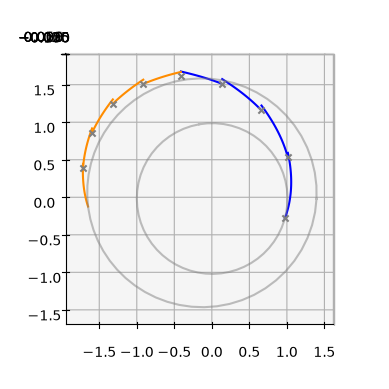

In [8]:
ax = plot_leg(leg, 100)
pk.plot.add_planet_orbit(ax, pl0, units=pk.AU, color = 'gray', alpha=0.5)
pk.plot.add_planet_orbit(ax, pl1, units=pk.AU, color = 'gray', alpha=0.5)

ax.view_init(90,-90)
ax.set_aspect('equal')


Unlike the forward/backward single-shooting leg, {class}`pykep.leg.zoh`, multiple shooting stores the interior node states as additional unknowns. An optimizer must adjust these states as well as the controls, so it needs an initial guess for them.

Both `zoh_ms` and `zoh_ms_py` provide `set_initial_guess(ballistic=False)`. This method preserves the endpoint states, controls and time grid, and rebuilds the interior nodes by propagating from both ends.

With `ballistic=False`, it uses the stored controls. If propagation succeeds, every segment except the one joining the forward and backward portions satisfies continuity, up to numerical error. With `ballistic=True`, it builds the nodes using zero controls, without changing the leg's stored controls. Evaluating that guess with nonzero stored controls can therefore produce defects in several segments.

These are starting guesses, not guaranteed feasible trajectories. Concentrating the defects into one segment does not necessarily reduce their total size.

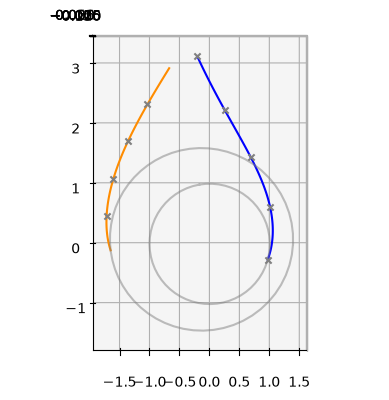

In [9]:
leg.set_initial_guess(ballistic=False)
ax = plot_leg(leg, 100)
pk.plot.add_planet_orbit(ax, pl0, units=pk.AU, color = 'gray', alpha=0.5)
pk.plot.add_planet_orbit(ax, pl1, units=pk.AU, color = 'gray', alpha=0.5)

ax.view_init(90,-90)
ax.set_aspect('equal')

# 2 - Use with a supplied generic propagator

The same leg interface works with other compatible dynamics. Here we use the **circular restricted three-body problem (CR3BP)**: a spacecraft moves under the gravity of Earth and Moon, whose circular motion is prescribed. The spacecraft's gravitational influence on the two bodies is neglected.

The state still contains position, velocity and mass, but position and velocity are now measured in the frame rotating with Earth and Moon. The origin is their centre of mass. The length unit is the Earth-Moon separation and the time unit is the inverse of their orbital angular speed. In these units the bodies remain at $(-\mu,0,0)$ and $(1-\mu,0,0)$, where $\mu$ is the Moon's fraction of their combined mass. Thrust directions are also expressed in this rotating frame.

We reuse the periodic Lyapunov-orbit reference from the single-shooting notebook to choose the initial mesh nodes. That reference uses zero thrust. We then apply nonzero controls to construct an intentionally infeasible leg and compare two guesses for its interior states. This section uses `zoh_ms_py`; replacing it with `zoh_ms` leaves the interface unchanged.

In [10]:
cr3bp_ta = pk.ta.get_zoh_cr3bp(tol)
cr3bp_ta_var = pk.ta.get_zoh_cr3bp_var(tol_var)
cr3bp_mu = 0.01215058560962404

# Parameters: thrust, three direction components, mass-flow coefficient and mass ratio.
# Zero thrust gives the reference orbit; the chosen mass-flow coefficient is 1.
cr3bp_pars = [0.0, 0.0, 0.0, 0.0, 1.0, cr3bp_mu]
cr3bp_ta.pars[:] = cr3bp_pars
cr3bp_ta_var.pars[:] = cr3bp_pars

# A reference initial state and period, expressed in the rotating-frame units.
cr3bp_state0 = [5.5643551520142581e-02, 9.2420772211102929e-27, 1.3616512785913887e-31, 2.6173746491479341e-12, 5.2390814115699671e+00, 5.3268092625591314e-30, 1.0]
cr3bp_period = 6.301205688481844

cr3bp_ta.time = 0.0
cr3bp_ta.state[:] = cr3bp_state0
cr3bp_reference = cr3bp_ta.propagate_grid(
    np.linspace(0.0, cr3bp_period, 1000)
)[-1]

We select an interval starting before and ending after the reference initial time, using the same boundary times as in the single-shooting example. Propagating the zero-thrust dynamics gives six nodes for a five-segment mesh. We then choose nonzero thrust in the rotating frame's positive $x$ direction, so these reference nodes are not a continuous solution for the leg's selected controls.

In [11]:
cr3bp_t0, cr3bp_tf = -cr3bp_period / 3, cr3bp_period / 5
cr3bp_nseg = 5
cr3bp_tgrid = np.linspace(cr3bp_t0, cr3bp_tf, cr3bp_nseg + 1)

# Reset the reference integrator and propagate to the mesh's first time.
cr3bp_ta.pars[:] = cr3bp_pars
cr3bp_ta.time = 0.0
cr3bp_ta.state[:] = cr3bp_state0
cr3bp_ta.propagate_until(cr3bp_t0)
cr3bp_nodes = cr3bp_ta.propagate_grid(cr3bp_tgrid)[-1]

# Apply nonzero thrust to the zero-thrust reference nodes.
cr3bp_controls = [0.3, 1.0, 0.0, 0.0] * cr3bp_nseg

Construct the leg from the reference nodes and selected controls, and overlay its propagated segments with the zero-thrust reference orbit. The gaps show that the initial mesh is infeasible. With the positive mass-flow coefficient, thrust also decreases mass, whereas all reference nodes have mass 1; this difference contributes to the defects.

In [12]:
cr3bp_leg = pk.leg.zoh_ms_py(
    cr3bp_nodes.flatten().tolist(),
    cr3bp_controls,
    cr3bp_tgrid,
    cut=0.5,
    tas=[cr3bp_ta, cr3bp_ta_var],
)

# Save the original continuity error before changing the interior nodes.
cr3bp_defect_norm_before = np.linalg.norm(cr3bp_leg.compute_defects())

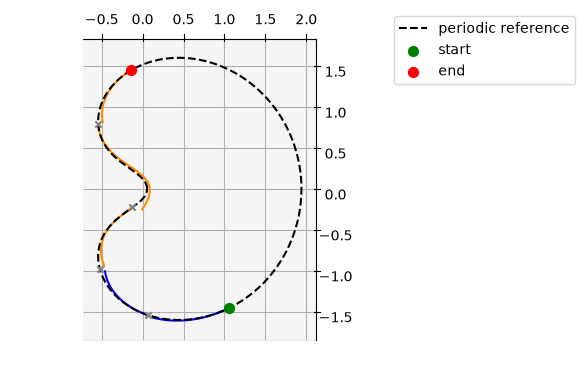

In [13]:
ax = plot_leg(cr3bp_leg, 100)
ax.plot(
    cr3bp_reference[:, 0],
    cr3bp_reference[:, 1],
    cr3bp_reference[:, 2],
    c="black",
    linestyle="--",
    label="periodic reference",
)
ax.scatter(*cr3bp_nodes[0, :3], c="green", marker="o", s=50, label="start")
ax.scatter(*cr3bp_nodes[-1, :3], c="red", marker="o", s=50, label="end")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.view_init(90, -90)
ax.set_zticks([])
ax.set_aspect("equal")


We now rebuild the interior nodes with `set_initial_guess(ballistic=False)`, which uses the stored nonzero controls. We compare the Euclidean norm of the full defect vector before and after this update, as well as the norm for each segment.

In [14]:
cr3bp_leg.set_initial_guess(ballistic=False)
cr3bp_defects_after = np.asarray(cr3bp_leg.compute_defects()).reshape(
    cr3bp_leg.nseg, cr3bp_leg.dim_dynamics
)
print(f"Defect norm before rebuilding: {cr3bp_defect_norm_before:.3f}")
print(f"Defect norm after rebuilding:  {np.linalg.norm(cr3bp_defects_after):.3f}")
print("Defect norm for each segment:", np.linalg.norm(cr3bp_defects_after, axis=1))

Defect norm before rebuilding: 1.111
Defect norm after rebuilding:  1.660
Defect norm for each segment: [ 0.          0.          1.65989136  0.          0.        ]


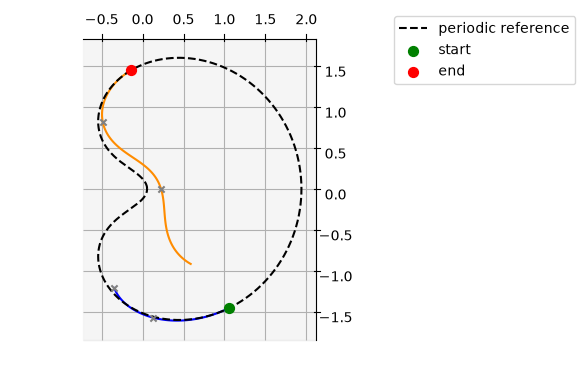

In [15]:
ax = plot_leg(cr3bp_leg, 100)
ax.plot(
    cr3bp_reference[:, 0],
    cr3bp_reference[:, 1],
    cr3bp_reference[:, 2],
    c="black",
    linestyle="--",
    label="periodic reference",
)
ax.scatter(*cr3bp_nodes[0, :3], c="green", marker="o", s=50, label="start")
ax.scatter(*cr3bp_nodes[-1, :3], c="red", marker="o", s=50, label="end")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.view_init(90, -90)
ax.set_zticks([])
ax.set_aspect("equal")

Rebuilding the interior nodes concentrates the continuity error into one segment, but does not necessarily reduce its size. Here the full defect norm increases. The new guess is therefore less feasible by this measure, even though four of the five segments now satisfy continuity.

The original nodes came from a zero-thrust reference orbit, not from a feasible trajectory with the selected nonzero controls. Both meshes are valid starting guesses for the leg. Their comparison shows why an initial-guess method can improve some continuity constraints while worsening the total error.